# **Customer Retention & RFM Segmentation — Olist Brazilian E-Commerce**

# **1. Business Understanding**

The primary objective of this analysis is to understand customer purchasing behavior and identify opportunities to improve customer retention and revenue. Through customer segmentation and data analysis, this project aims to answer key business questions and provide actionable recommendations.

### **2. Business Objectives**

• Identify high-value and low-value customer segments. 

• Analyze customer purchasing behavior and buying patterns.

• Identify customers who are at risk of churn.

• Recommend strategies to improve customer retention and revenue growth.

• Generate data-driven business insights to support decision making.

### **Business Questions**
• Who are the most valuable customers?

• Which customer segments contribute the highest revenue?

• Which customers are at risk of churn?

• What purchasing patterns can be observed?

• What recommendations can improve customer retention?

### **Dataset Discription**

The analysis is performed using the **Olist Brazilian E-Commerce Dataset**, a publicly available dataset from Kaggle that contains transactional data from a Brazilian e-commerce marketplace. The dataset follows a relational database structure, where multiple tables are connected through customer and order identifiers. The database schema is provided in `/images/database_schema.png`.

Dataset link : https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

For this project, only the tables required to answer the business objectives are used. The primary datasets include customer information, order details, payment records, and order item information. Additional tables such as product information and customer reviews may be incorporated later to perform category-level analysis and customer satisfaction analysis.

The relational structure of the dataset enables comprehensive customer-level analysis by combining information across multiple tables. This makes it suitable for customer segmentation, purchasing behavior analysis, revenue analysis, retention analysis, and generating business recommendations.



### **SQL Analysis**

The `sql/` directory contains SQL equivalents of the major analytical workflows implemented in Python/Pandas. These queries demonstrate how the same RFM, cohort, revenue, product, and payment analyses can be performed using SQL.

The project uses a business-rule-based Frequency score in the final segmentation because the customer purchase-frequency distribution is highly skewed toward one-time buyers.

In [1]:
import warnings 
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

## **3. Data Loading & Dataset Overview**

In [2]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")

customers = pd.read_csv("../data/olist_customers_dataset.csv")

payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

items = pd.read_csv("../data/olist_order_items_dataset.csv")

products = pd.read_csv("../data/olist_products_dataset.csv")

In [3]:
def inspect_df(df, name):
    print("=" * 60)
    print(f"{name.upper()} DATASET")
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nSample:")
    display(df.sample(5))

    print("\nInfo:")
    df.info()

    print("\nDescribe:")
    display(df.describe(include="all"))

    print("\nMissing Values:")
    display(df.isnull().sum())

    print("\nDuplicates:")
    print(df.duplicated().sum())

In [4]:
datasets = {
    "Orders": orders,
    "Customers": customers,
    "Payments": payments,
    "Order Items": items
}

for name, df in datasets.items():
    inspect_df(df, name)

ORDERS DATASET

Shape:
(99441, 8)

Sample:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
11530,387ca56ee49ac7729110f669eeb9e3cf,f1c60a312bea019a3f8d4e38fd7f00aa,delivered,2018-06-21 21:54:29,2018-06-21 22:17:59,2018-06-22 13:51:00,2018-06-29 14:51:58,2018-07-16 00:00:00
43285,0647c4896cbb3bcfe3a48f652dd058ca,f74fb337ed11fedba7605dbf08af6c8e,delivered,2018-02-26 14:06:11,2018-02-26 14:29:47,2018-02-27 00:06:28,2018-03-07 14:18:47,2018-03-19 00:00:00
5413,3dc3b1441a6356bd23b21ac507bd38d6,44ecc84cbb68a3b1cd5015298222b71a,delivered,2018-03-28 12:27:21,2018-03-28 12:47:38,2018-03-29 22:38:30,2018-04-02 22:04:29,2018-04-10 00:00:00
53736,a10b332599146f5dbbbb25f38dd85fc1,7663f2fefb813c164a83a2cf5b653e6b,delivered,2017-07-09 22:36:56,2017-07-09 22:50:14,2017-07-11 14:06:30,2017-07-18 19:13:16,2017-08-02 00:00:00
48183,5f082c0821ef7e1812362878c7268aef,31dbc13addc753e210692eacaea065e4,delivered,2017-11-18 00:58:41,2017-11-18 01:15:33,2017-11-27 15:42:37,2017-12-29 01:48:17,2017-12-28 00:00:00



Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

Describe:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522



Missing Values:


...


Info:
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB

Describe:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000



Missing Values:


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


Duplicates:
0


### Orders Dataset
- Dataset contains 99,441 orders and 8 columns.
- Several date-related columns are stored as object and will be converted to datetime for time-based analysis.
- Missing values are present in order_approved_at, order_delivered_carrier_date, and order_delivered_customer_date. These will be investigated before any cleaning decisions are made.
- No duplicate records were found.

### Customers Dataset
- Dataset contains 99,441 customer records.
- All columns have appropriate data types.
- No missing values or duplicate records were found.
- This table will be used to identify unique customers and perform location-based analysis.

### Payments Dataset
- Dataset contains 103,886 payment records, indicating that some orders have multiple payment entries.
- No missing values or duplicate records were found.
- Data types are appropriate for further monetary analysis.

### Order Items Dataset
- Dataset contains 112,650 order item records, indicating that an order may contain multiple products.
- shipping_limit_date is stored as a string and will be converted to datetime.
- No missing values or duplicate records were found.

In [5]:
orders.groupby("order_status")[
    [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
    ]
].apply(lambda x: x.isnull().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [6]:
orders.isnull().mean()*100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.160899
order_delivered_carrier_date     1.793023
order_delivered_customer_date    2.981668
order_estimated_delivery_date    0.000000
dtype: float64

## **4. Data Preparation**

- Datetime columns will be converted using pd.to_datetime().

- Missing delivery-related timestamps are expected for orders that were canceled, unavailable, or are still in progress.

- A very small number of delivered orders also contain missing timestamps, which may indicate data quality issues.

- Since delivery timestamps are not required for RFM analysis, these missing values will not be imputed at this stage.

In [7]:
datetime_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in datetime_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [8]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [9]:
items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"], errors="coerce")

In [10]:
items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [11]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


### **4.1 Joins**

In [12]:
payment_summary = payments.groupby("order_id").agg(
    total_payment=("payment_value", sum)
).reset_index()

In [13]:
items_summary = items.groupby("order_id").agg(
    total_price = ("price", "sum"),
    total_freight = ("freight_value", "sum"),
    total_items = ("order_item_id", "count")
).reset_index()

In [14]:
master_df = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(payment_summary, on="order_id", how="left")
    .merge(items_summary, on="order_id", how="left")
)

In [15]:
master_df.shape

(99441, 16)

In [16]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,total_price,total_freight,total_items
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,29.99,8.72,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,118.70,22.76,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,159.90,19.22,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,45.00,27.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,19.90,8.72,1.0


In [17]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   customer_unique_id             99441 non-null  str           
 9   customer_zip_code_prefix       99441 non-null  int64         
 10  customer_city                  99441 non-null  str           
 11  customer_state            

## **5. RFM Analysis**

In [18]:
rfm_df = master_df[master_df['order_status'] == "delivered"].copy()

In [19]:
rfm_df.shape

(96478, 16)

### **5.1 Recency, Frequency & Monetary**

In [20]:
rfm = rfm_df.groupby('customer_unique_id').agg(
    LastPurchase=("order_purchase_timestamp", "max"),
    Frequency=("order_id", "nunique"),
    Monetary=("total_payment", "sum"),
)

In [21]:
refrence_date = rfm['LastPurchase'].max() + pd.Timedelta(days=1)

rfm["Recency"] = (refrence_date - rfm['LastPurchase']).dt.days

In [22]:
rfm.drop(columns={"LastPurchase"}, inplace=True)
rfm = rfm[["Recency", "Frequency", "Monetary"]]

In [23]:
rfm.describe()

,Recency,Frequency,Monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


In [24]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=4,
    labels=[4, 3, 2, 1]
)

I used pd.qcut() because RFM scoring is percentile-based. It divides customers into equal-sized groups (quantiles), allowing fair comparison of customer behavior even when the data distribution is skewed.

In [25]:
rfm["Frequency"].value_counts().head(10)

Frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

The frequency distribution was highly skewed, with most customers placing only one order. Quantile binning could not create meaningful quartiles, so I used business-rule-based scoring to create interpretable customer segments.

## **6. RFM Scoring & Customer Segmentation**

In [26]:
def frequency_score(x):
    if x == 1:
        return 1
    elif x == 2:
        return 2
    elif 3 <= x <= 4:
        return 3
    else:
        return 4

rfm["F_Score"] = rfm["Frequency"].apply(frequency_score)

In [27]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1


In [28]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=4,
    labels=[1,2,3,4]
)

In [29]:
rfm["rfm_score"] = (
    rfm['R_Score'].astype(str)+
    rfm['F_Score'].astype(str)+
    rfm['M_Score'].astype(str)
)

In [30]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,rfm_score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


Frequency scoring was performed using business-defined thresholds instead of quantile binning because the frequency distribution was highly skewed. More than 90,000 customers had only one purchase, making quartile-based segmentation unsuitable.

## **7. Segment Validation**

In [31]:
def segment_customer(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r == 4 and f >= 3 and m >= 3:
        return "Champions"

    elif r >= 3 and f >= 2:
        return "Loyal Customers"

    elif r == 4 and f == 1:
        return "Potential Loyalists"

    elif r == 2 and f == 1:
        return "Needs Attention"

    elif r == 1 and f >= 2:
        return "At Risk"

    else:
        return "Lost"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [32]:
rfm["Segment"].value_counts()

Segment
Lost                   46090
Potential Loyalists    22613
Needs Attention        22527
Loyal Customers         1474
At Risk                  579
Champions                 75
Name: count, dtype: int64

In [33]:
rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

,Recency,Frequency,Monetary
Segment,,,
At Risk,439.65,2.08,291.54
Champions,57.77,3.61,627.89
Lost,308.88,1.02,162.02
Loyal Customers,115.77,2.07,298.80
Needs Attention,277.33,1.00,158.73
Potential Loyalists,57.50,1.00,164.64


If Potential Loyalists can be encouraged to make repeat purchases, they have a high chance of becoming Champions.

## **8. Customer & Revenue Visualizations**

**8.1 How is the customer base distributed across segments?**

In [34]:
segment_counts = rfm["Segment"].value_counts()

segment_distributions = pd.DataFrame({
    "Customer count" : segment_counts,
    "Percentage" : (segment_counts/len(rfm)*100).round(2)
})

segment_distributions

,Customer count,Percentage
Segment,,
Lost,46090,49.37
Potential Loyalists,22613,24.22
Needs Attention,22527,24.13
Loyal Customers,1474,1.58
At Risk,579,0.62
Champions,75,0.08


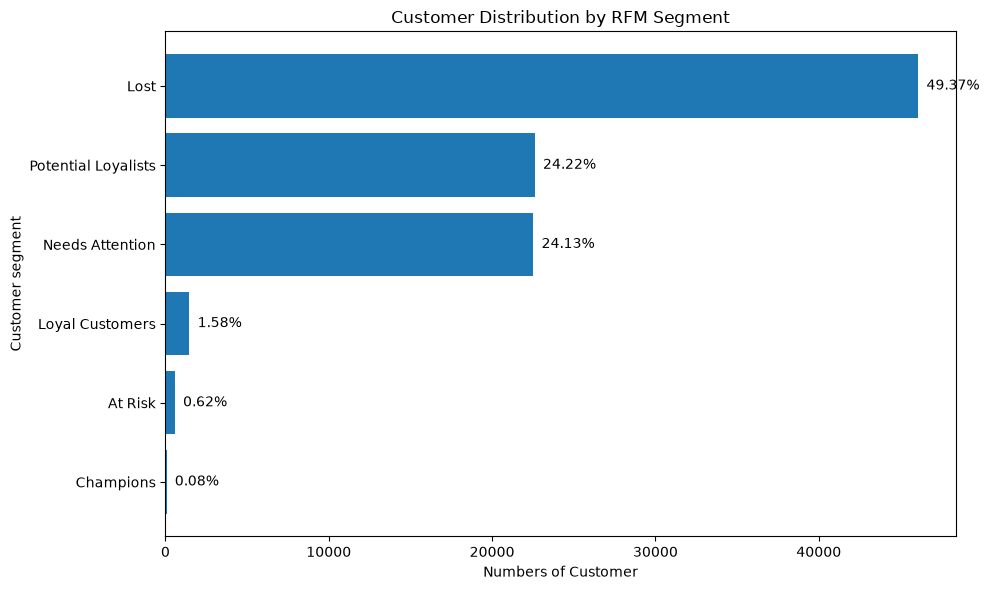

In [35]:
plt.figure(figsize=(10,6))

plot_data = segment_distributions.sort_values("Customer count")

bars = plt.barh(
    plot_data.index,
    plot_data["Customer count"]
)

plt.xlabel("Numbers of Customer")
plt.ylabel("Customer segment")
plt.title(("Customer Distribution by RFM Segment"))

for bar, percentage in zip(bars, plot_data["Percentage"]):
    plt.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height()/2,
        f"{percentage:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

**Business Takeaway:**  
The customer base is heavily concentrated in the Lost segment, which accounts for 49.37% of all customers. Potential Loyalists (24.22%) and Needs Attention (24.13%) together represent 48.35% of the customer base, indicating a large opportunity for customer re-engagement and conversion.

**8.2 Which segments actually matter financially?**

In [36]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue_distribution = pd.DataFrame({
    "Total Revenue": segment_revenue,
    "Revenue Percentage" : (
        segment_revenue/segment_revenue.sum() * 100
    ).round(2)
})

segment_revenue_distribution

,Total Revenue,Revenue Percentage
Segment,,
Lost,7467322.92,48.42
Potential Loyalists,3723035.41,24.14
Needs Attention,3575773.85,23.19
Loyal Customers,440435.53,2.86
At Risk,168802.35,1.09
Champions,47091.71,0.31


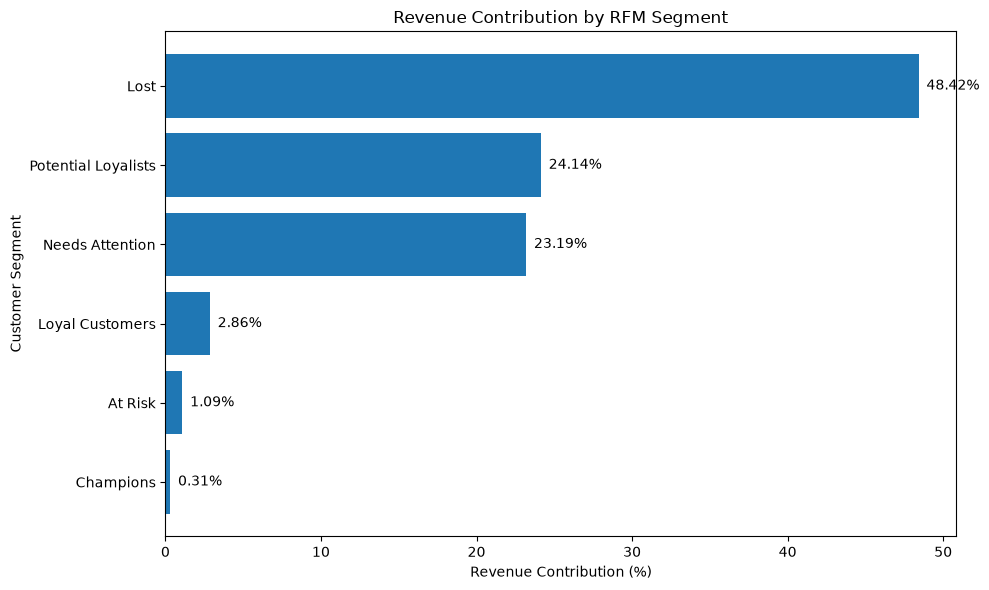

In [37]:
plt.figure(figsize=(10, 6))

plot_data = segment_revenue_distribution.sort_values("Revenue Percentage")

bars = plt.barh(
    plot_data.index,
    plot_data["Revenue Percentage"]
)

plt.xlabel("Revenue Contribution (%)")
plt.ylabel("Customer Segment")
plt.title("Revenue Contribution by RFM Segment")

for bar, percentage in zip(bars, plot_data["Revenue Percentage"]):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

**Business Takeaway:**  
The Lost segment contributes 48.42% of total revenue while representing 49.37% of customers. Although Champions account for only 0.08% of customers, they contribute 0.31% of revenue, while Loyal Customers contribute 2.86% of revenue from just 1.58% of customers. This indicates that smaller high-value segments contribute disproportionately more revenue per customer.

**8.3 Which segment has the highest average customer value?**

In [38]:
avg_monetary = (
    rfm.groupby("Segment")["Monetary"]
    .mean()
    .sort_values(ascending=False)
)

avg_monetary

Segment
Champions              627.889467
Loyal Customers        298.802938
At Risk                291.541192
Potential Loyalists    164.641375
Lost                   162.016119
Needs Attention        158.732803
Name: Monetary, dtype: float64

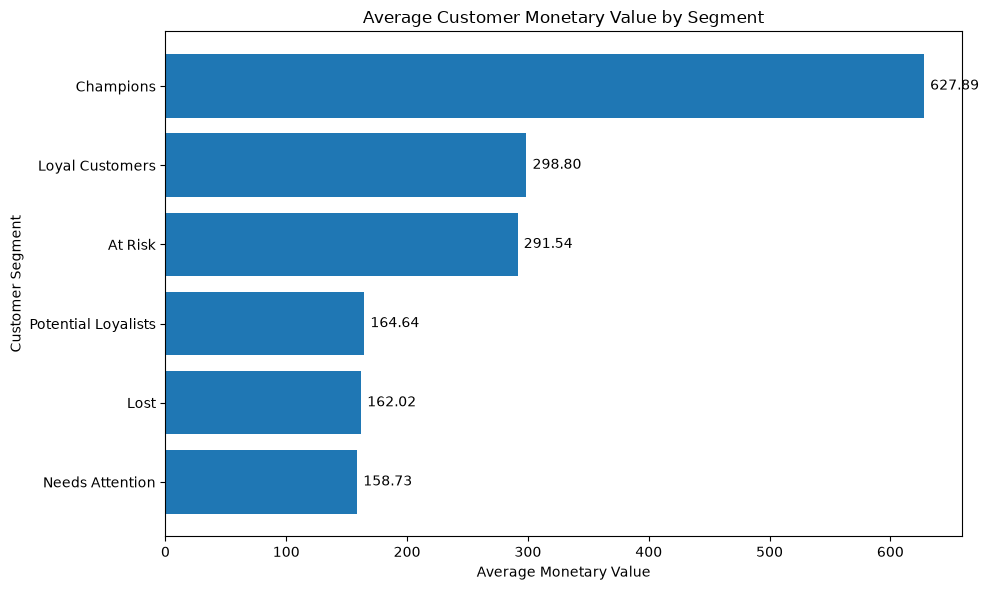

In [39]:
plt.figure(figsize=(10,6))

plot_data = avg_monetary.sort_values()

bars = plt.barh(
    plot_data.index,
    plot_data.values
)

plt.xlabel("Average Monetary Value")
plt.ylabel("Customer Segment")
plt.title("Average Customer Monetary Value by Segment")

for bar, value in zip(bars, plot_data.values):
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

**Business Takeaway:**  
Champions have the highest average Monetary value at 627.89, while Needs Attention customers have the lowest at 158.73. Champions therefore generate approximately 3.96 times the average monetary value of Needs Attention customers, highlighting their importance as a high-value customer segment.

**8.4 Which customer segments make purchases more frequently?**

In [40]:
avg_frequency = (
    rfm.groupby("Segment")["Frequency"]
    .mean()
    .sort_values(ascending=False)
)

avg_frequency

Segment
Champions              3.613333
At Risk                2.082902
Loyal Customers        2.067164
Lost                   1.015708
Needs Attention        1.000000
Potential Loyalists    1.000000
Name: Frequency, dtype: float64

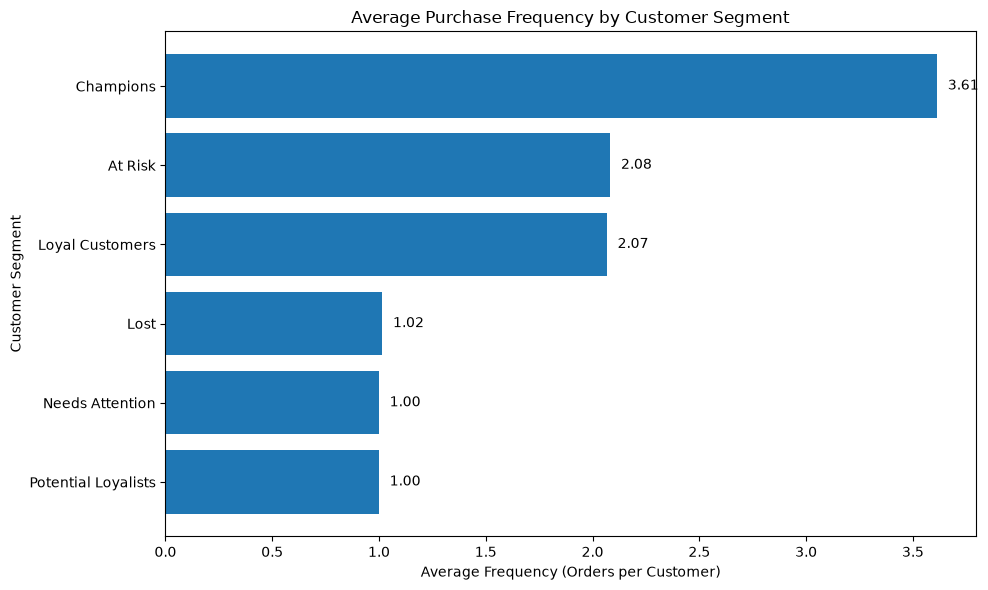

In [41]:
plt.figure(figsize=(10, 6))

plot_data = avg_frequency.sort_values()

bars = plt.barh(
    plot_data.index,
    plot_data.values
)

plt.xlabel("Average Frequency (Orders per Customer)")
plt.ylabel("Customer Segment")
plt.title("Average Purchase Frequency by Customer Segment")

for bar, value in zip(bars, plot_data.values):

    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

**Business Takeaway:**  
Champions have the highest average purchase frequency at 3.61 orders per customer, while Potential Loyalists and Needs Attention customers average only 1.00 order per customer. This highlights a clear difference between repeat-purchase customers and predominantly one-time buyers.

**8.5 Which customer segments have purchased most recently, and which have been inactive for longer?**

In [42]:
avg_recency = (
    rfm.groupby("Segment")["Recency"]
    .mean()
    .sort_values()
)

avg_recency

Segment
Potential Loyalists     57.500774
Champions               57.773333
Loyal Customers        115.767978
Needs Attention        277.334399
Lost                   308.883923
At Risk                439.647668
Name: Recency, dtype: float64

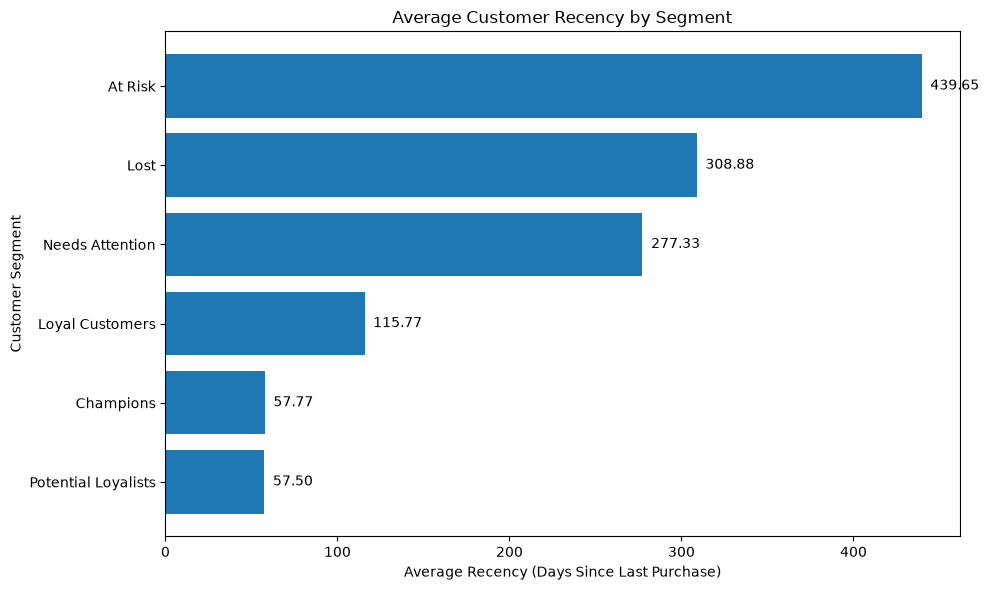

In [43]:
plt.figure(figsize=(10, 6))

plot_data = avg_recency.sort_values()

bars = plt.barh(
    plot_data.index,
    plot_data.values
)

plt.xlabel("Average Recency (Days Since Last Purchase)")
plt.ylabel("Customer Segment")
plt.title("Average Customer Recency by Segment")

for bar, value in zip(bars, plot_data.values):
    
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()


**Business Takeaway:**  
Potential Loyalists and Champions have the lowest average recency at 57.50 and 57.77 days respectively, indicating that these customers purchased most recently. In contrast, At Risk customers have the highest average recency at 439.65 days, followed by Lost customers at 308.88 days, indicating substantially longer periods since their last purchase.

### **Recency vs Frequency by Customer Segment**

**8.6 Can we identify patterns between customer recency and purchase frequency across different customer segments?**  


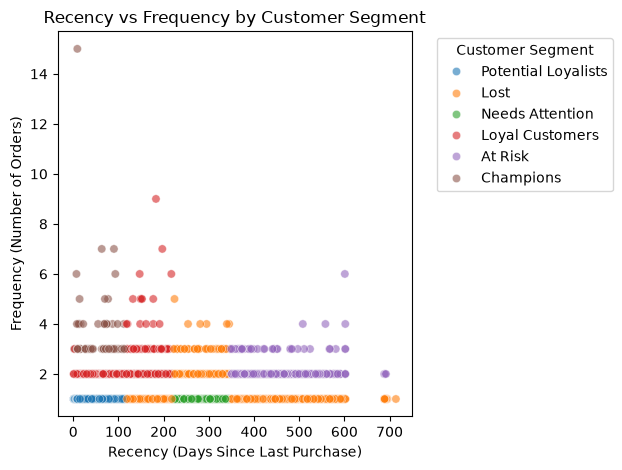

In [44]:
plt.Figure(figsize=(10, 6))

sns.scatterplot(
    data = rfm,
    x='Recency',
    y='Frequency',
    hue='Segment',
    alpha=0.6
)

plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Frequency (Number of Orders)")
plt.title("Recency vs Frequency by Customer Segment")

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Business Takeaway:**  
The scatter plot shows a strong concentration of customers at low purchase frequencies, particularly around 1–3 orders. Recency is also concentrated within the lower range, while a smaller number of customers show substantially higher recency values. This reflects the dataset's large population of predominantly one-time buyers and a smaller group of repeat or highly inactive customers.

### **RFM Metric Distributions**

**8.7 How are Recency, Frequency, and Monetary values distributed across customers?**  


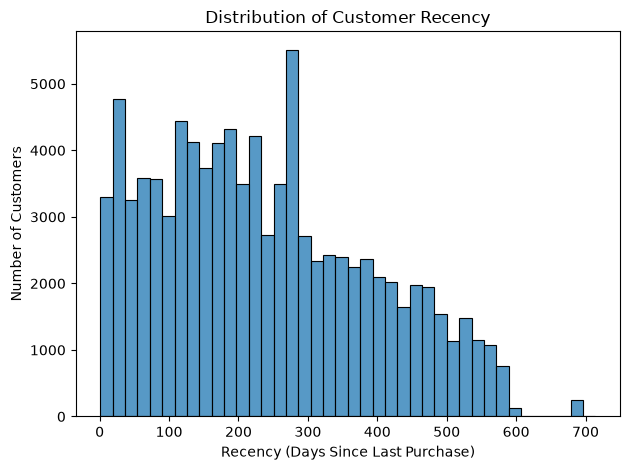

In [45]:
plt.Figure(figsize=(10, 6))

sns.histplot(
    data = rfm,
    x='Recency',
    bins=40
)

plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Recency")

plt.tight_layout()
plt.show()

**Business Takeaway:**  
Customer Recency is broadly distributed across the observed period, with noticeable concentration around several time ranges rather than a single dominant point. Customer counts remain relatively substantial through the middle of the recency range before declining at higher recency values, indicating that the customer base contains both relatively recent purchasers and a sizeable group with longer periods since their last purchase.

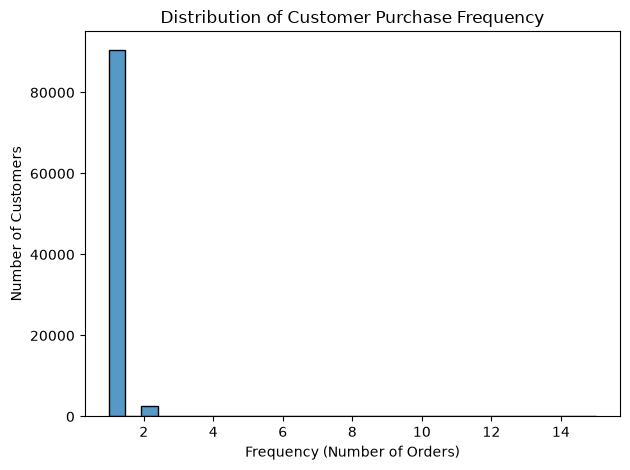

In [46]:
plt.Figure(figsize=(10, 6))

sns.histplot(
    data = rfm,
    x = 'Frequency',
    bins=30
)

plt.xlabel("Frequency (Number of Orders)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Purchase Frequency")

plt.tight_layout()
plt.show()

**Business Takeaway:**  
Customer purchase frequency is highly right-skewed, with the vast majority of customers concentrated at a frequency of 1. Approximately 90,557 customers made only one purchase, while customers with higher purchase frequencies form a relatively small long tail. This strong concentration of one-time buyers explains why a business-rule-based Frequency scoring approach was preferred over quantile-based scoring.

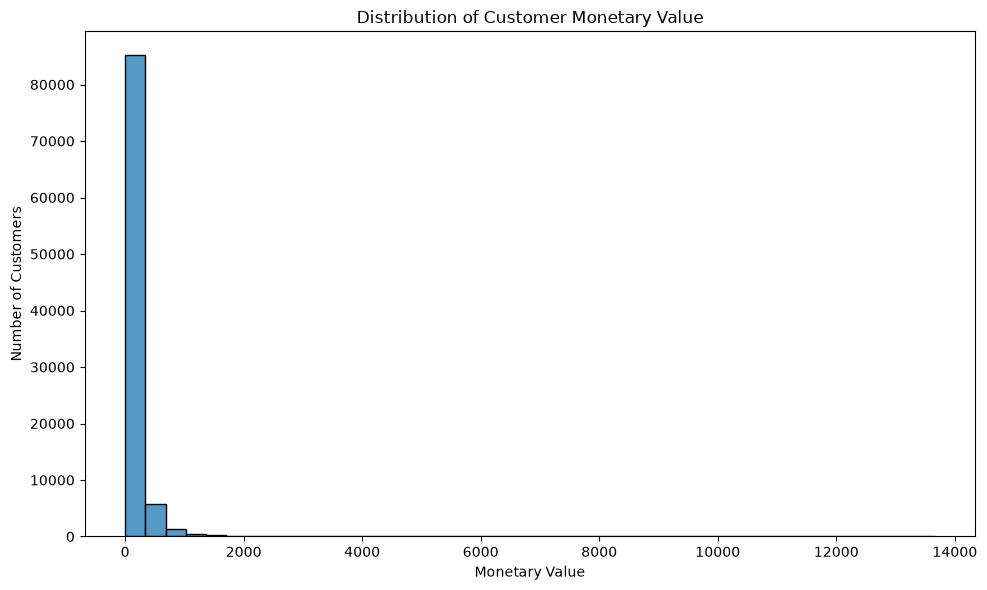

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=rfm,
    x="Monetary",
    bins=40
)

plt.xlabel("Monetary Value")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Monetary Value")

plt.tight_layout()
plt.show()

**Business Takeaway:**  
Customer Monetary value is highly right-skewed, with most customers concentrated at relatively low spending levels and a small number of customers forming a long high-value tail. This indicates substantial variation in customer value, with a limited group of customers contributing considerably higher individual monetary values.

### **Monthly Revenue Trend**

**8.8 How did revenue change over the observed period?**  

In [48]:
delivered_orders = master_df[
    master_df["order_status"] == "delivered"
].copy()

monthly_revenue = (
    delivered_orders
    .assign(
        PurchaseMonth=delivered_orders["order_purchase_timestamp"].dt.to_period("M")
    )
    .groupby("PurchaseMonth")["total_payment"]
    .sum()
)

monthly_revenue

PurchaseMonth
2016-09          0.00
2016-10      46566.71
2016-12         19.62
2017-01     127545.67
2017-02     271298.65
2017-03     414369.39
2017-04     390952.18
2017-05     567066.73
2017-06     490225.60
2017-07     566403.93
2017-08     646000.61
2017-09     701169.99
2017-10     751140.27
2017-11    1153528.05
2017-12     843199.17
2018-01    1078606.86
2018-02     966510.88
2018-03    1120678.00
2018-04    1132933.95
2018-05    1128836.69
2018-06    1012090.68
2018-07    1027903.86
2018-08     985414.28
Freq: M, Name: total_payment, dtype: float64

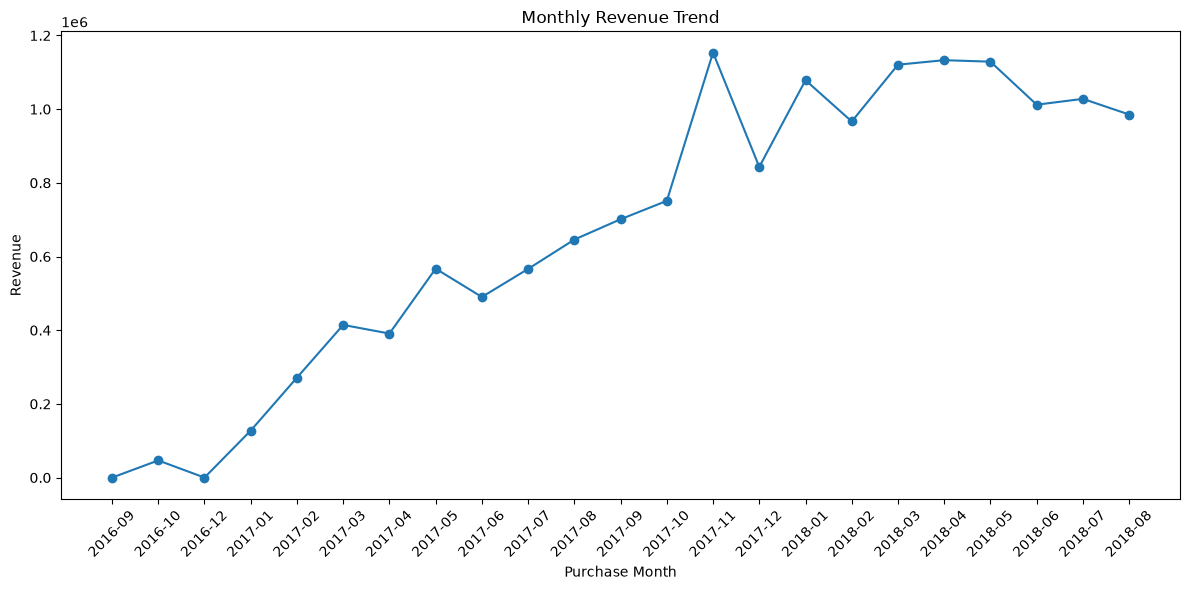

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.xlabel("Purchase Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Business Takeaway:**  
Monthly revenue shows a substantial increase over the observed period, rising from relatively low levels in early 2017 to consistently higher monthly revenue throughout 2018. Revenue reaches its highest observed level in November 2017 at approximately 1.15 million, followed by a noticeable decline in December and recovery in early 2018. From March to May 2018, monthly revenue remains around 1.1 million before moderating during the final months of the observed period.

The pronounced November peak followed by a December decline suggests possible seasonal variation in purchasing activity, although the underlying cause cannot be established from revenue data alone.

### **Product Category Revenue**

**8.9 Which product categories generate the most revenue?**  


In [50]:
delivered_order_ids = orders.loc[
    orders["order_status"] == "delivered",
    "order_id"
]

category_revenue = (
    items[items["order_id"].isin(delivered_order_ids)]
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name
beleza_saude              1233131.72
relogios_presentes        1166176.98
cama_mesa_banho           1023434.76
esporte_lazer              954852.55
informatica_acessorios     888724.61
moveis_decoracao           711927.69
utilidades_domesticas      615628.69
cool_stuff                 610204.10
automotivo                 578966.65
brinquedos                 471286.48
Name: price, dtype: float64

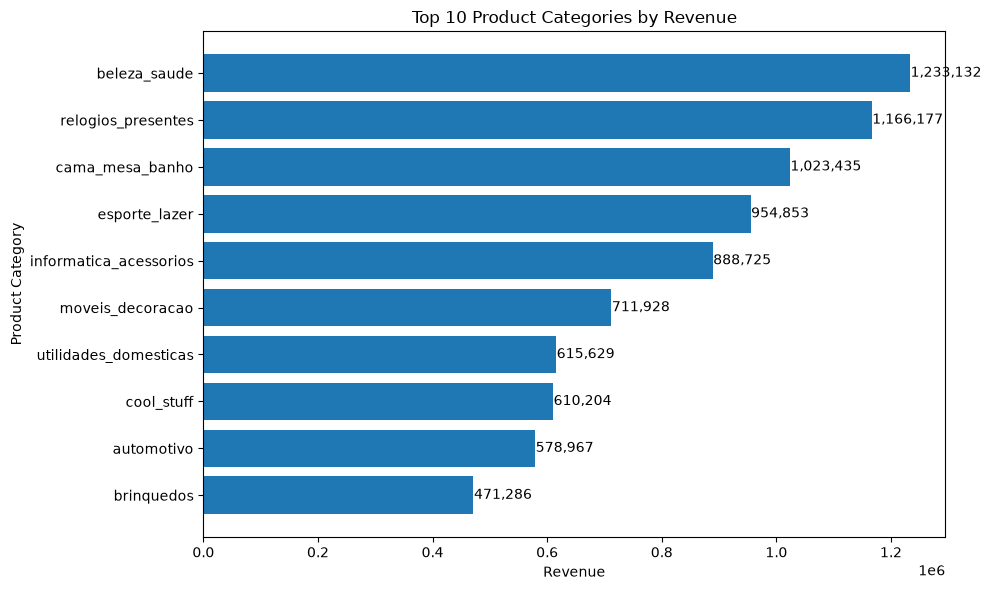

In [51]:
plot_data = category_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data.index,
    plot_data.values
)

plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.title("Top 10 Product Categories by Revenue")

for bar, value in zip(bars, plot_data.values):

    plt.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

**Business Takeaway:**  
Beauty & Health generates the highest revenue among the top 10 product categories at approximately 1.23 million, followed by Watches & Gifts at 1.17 million and Bed, Bath & Table at 1.02 million. The remaining top categories generate progressively lower revenue, with Toys contributing approximately 0.47 million. This indicates that revenue is distributed across several major product categories rather than being concentrated in a single category.

### **Payment Method Distribution**

**8.10 How do customers distribute their payments across different payment methods?**  


In [52]:
payment_distribution = (
    payments["payment_type"]
    .value_counts()
)

payment_distribution

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

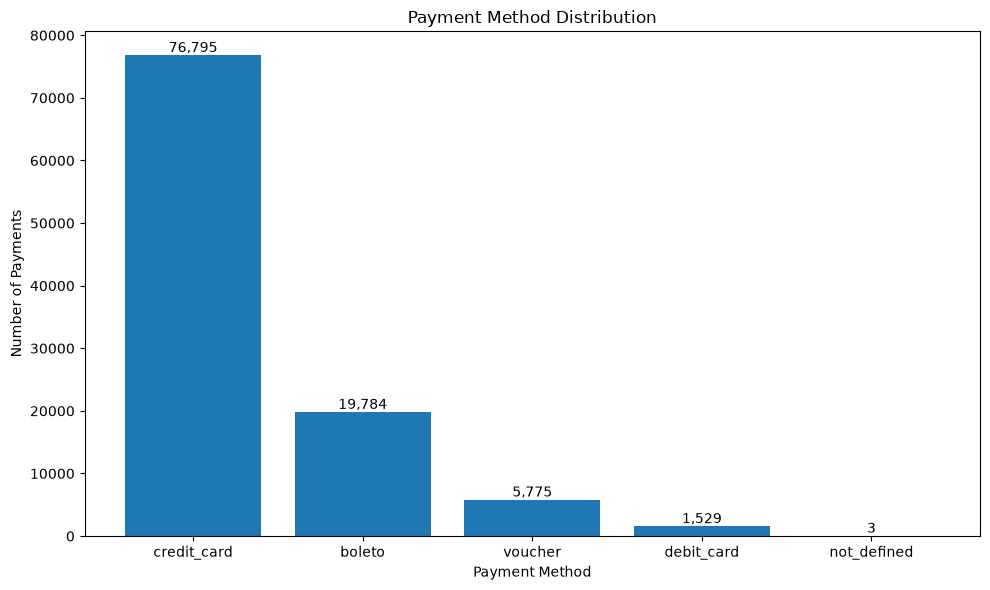

In [53]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    payment_distribution.index,
    payment_distribution.values
)

plt.xlabel("Payment Method")
plt.ylabel("Number of Payments")
plt.title("Payment Method Distribution")

for bar, value in zip(bars, payment_distribution.values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [54]:
payment_percentage = (
    payment_distribution
    / payment_distribution.sum()
    * 100
)

payment_percentage

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: count, dtype: float64

**Business Takeaway:**  
Credit card is the dominant payment method, accounting for 73.92% of recorded payment transactions. Boleto is the second most common method at 19.04%, followed by vouchers at 5.56% and debit cards at 1.47%. The remaining not_defined category accounts for only 0.003% of transactions. Overall, payment activity is highly concentrated in credit card and boleto transactions.

## **9. Cohort & Retention Analysis**

**Business Question:**  
How well do customers continue purchasing after their first purchase?

In [55]:
first_purchase = (
    delivered_orders
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase["CohortMonth"] = (
    first_purchase["order_purchase_timestamp"]
    .dt.to_period("M")
)


first_purchase.head()

,customer_unique_id,order_purchase_timestamp,CohortMonth
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11


In [56]:
delivered_orders["PurchaseMonth"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

cohort_data = delivered_orders.merge(
    first_purchase[["customer_unique_id", "CohortMonth"]],
    on="customer_unique_id",
    how="left"
)

cohort_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,total_price,total_freight,total_items,PurchaseMonth,CohortMonth
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,29.99,8.72,1.0,2017-10,2017-09
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,118.70,22.76,1.0,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,159.90,19.22,1.0,2018-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,45.00,27.20,1.0,2017-11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,19.90,8.72,1.0,2018-02,2018-02


In [57]:
cohort_data["CohortIndex"] = (
    (cohort_data["PurchaseMonth"].dt.year - cohort_data["CohortMonth"].dt.year) * 12
    + (cohort_data["PurchaseMonth"].dt.month - cohort_data["CohortMonth"].dt.month)
)

cohort_data[
    ["customer_unique_id", "PurchaseMonth", "CohortMonth", "CohortIndex"]
].head(10)

,customer_unique_id,PurchaseMonth,CohortMonth,CohortIndex
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07,0
6,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05,0
7,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01,0
8,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07,0
9,f2a85dec752b8517b5e58a06ff3cd937,2017-05,2017-05,0


In [58]:
cohort_counts = (
    cohort_data
    .groupby(["CohortMonth", "CohortIndex"])["customer_unique_id"]
    .nunique()
    .unstack(fill_value=0)
)

cohort_counts

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2016-10,262,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1,0,1,2,2
2016-12,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2017-01,717,2,2,1,3,1,3,1,1,0,3,1,5,3,1,1,2,3,1,0
2017-02,1628,3,5,2,7,2,4,3,2,3,2,5,2,3,2,1,1,3,0,0
2017-03,2503,11,9,10,9,4,4,8,8,2,9,3,5,3,4,6,2,3,0,0
2017-04,2256,14,5,4,6,6,8,7,7,4,6,2,1,1,2,2,3,0,0,0
2017-05,3451,16,16,10,10,11,14,5,9,9,9,12,8,1,6,7,0,0,0,0
2017-06,3037,15,12,13,9,12,11,7,4,6,9,11,5,5,7,0,0,0,0,0


In [59]:
retention = cohort_counts.div(
    cohort_counts.iloc[:, 0],
    axis=0
) * 100

retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.381679,0.000000,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.763359,0.763359
2016-12,100.0,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01,100.0,0.278940,0.278940,0.139470,0.418410,0.139470,0.418410,0.139470,0.139470,0.000000,0.418410,0.139470,0.697350,0.418410,0.139470,0.139470,0.278940,0.418410,0.139470,0.000000
2017-02,100.0,0.184275,0.307125,0.122850,0.429975,0.122850,0.245700,0.184275,0.122850,0.184275,0.122850,0.307125,0.122850,0.184275,0.122850,0.061425,0.061425,0.184275,0.000000,0.000000
2017-03,100.0,0.439473,0.359569,0.399521,0.359569,0.159808,0.159808,0.319616,0.319616,0.079904,0.359569,0.119856,0.199760,0.119856,0.159808,0.239712,0.079904,0.119856,0.000000,0.000000
2017-04,100.0,0.620567,0.221631,0.177305,0.265957,0.265957,0.354610,0.310284,0.310284,0.177305,0.265957,0.088652,0.044326,0.044326,0.088652,0.088652,0.132979,0.000000,0.000000,0.000000
2017-05,100.0,0.463634,0.463634,0.289771,0.289771,0.318748,0.405680,0.144886,0.260794,0.260794,0.260794,0.347725,0.231817,0.028977,0.173863,0.202840,0.000000,0.000000,0.000000,0.000000
2017-06,100.0,0.493908,0.395127,0.428054,0.296345,0.395127,0.362200,0.230491,0.131709,0.197563,0.296345,0.362200,0.164636,0.164636,0.230491,0.000000,0.000000,0.000000,0.000000,0.000000


In [60]:
retention_clean = retention.copy()

max_month = cohort_data["PurchaseMonth"].max()

for cohort in retention_clean.index:
    cohort_period = pd.Period(cohort, freq="M")
    
    for month_index in retention_clean.columns:
        if cohort_period + month_index > max_month:
            retention_clean.loc[cohort, month_index] = np.nan

In [61]:
retention_clean.iloc[:, :6]

CohortIndex,0,1,2,3,4,5
CohortMonth,,,,,,
2016-09,100.0,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,100.0,0.000000,0.000000,0.000000,0.000000,0.000000
2016-12,100.0,100.000000,0.000000,0.000000,0.000000,0.000000
2017-01,100.0,0.278940,0.278940,0.139470,0.418410,0.139470
2017-02,100.0,0.184275,0.307125,0.122850,0.429975,0.122850
2017-03,100.0,0.439473,0.359569,0.399521,0.359569,0.159808
2017-04,100.0,0.620567,0.221631,0.177305,0.265957,0.265957
2017-05,100.0,0.463634,0.463634,0.289771,0.289771,0.318748
2017-06,100.0,0.493908,0.395127,0.428054,0.296345,0.395127


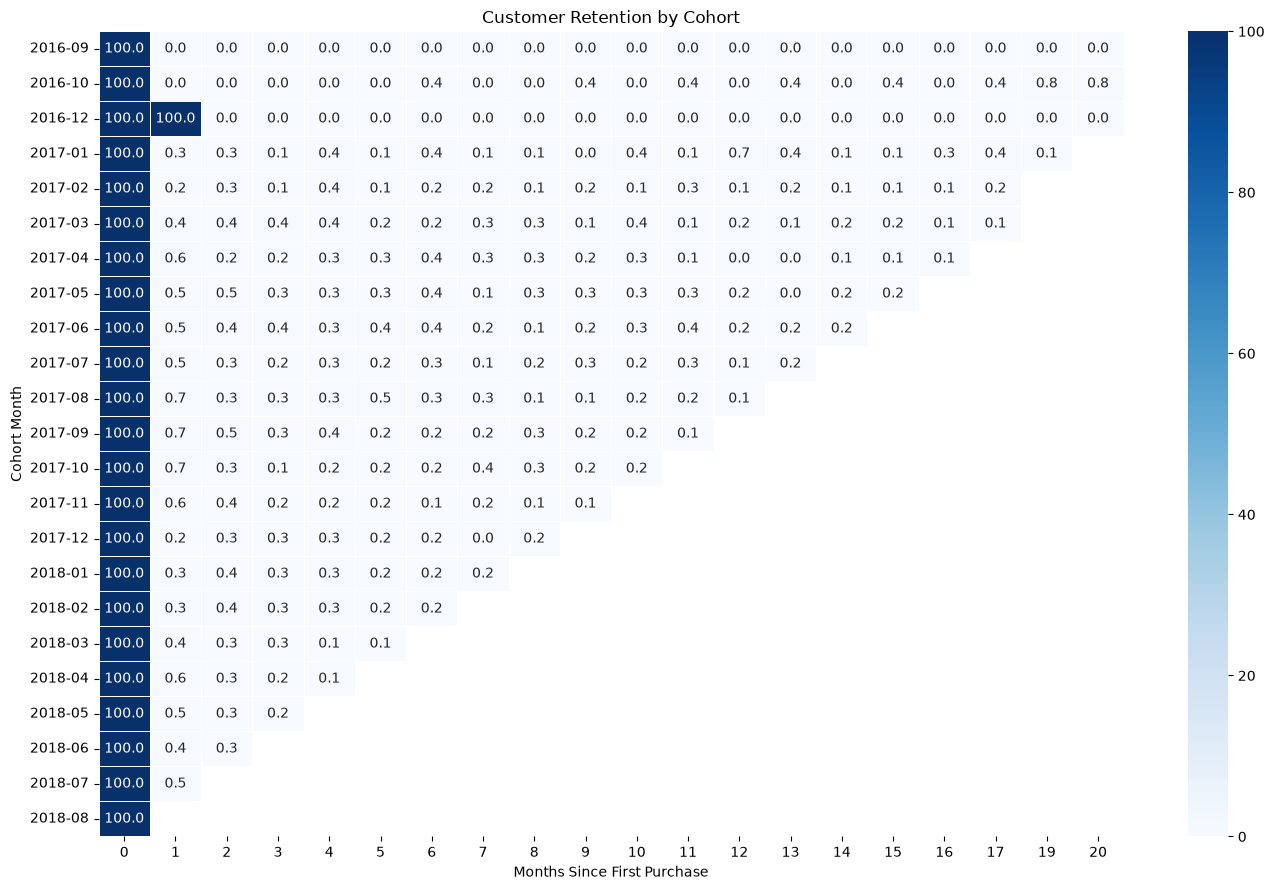

In [62]:
plt.figure(figsize=(14, 9))

sns.heatmap(
    retention_clean,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.5
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.title("Customer Retention by Cohort")

plt.tight_layout()
plt.show()

**Business Takeaway:**  
Retention drops sharply after the initial purchase, with Month-1 retention remaining below 1% across major cohorts. The highest Month-1 retention is observed for the October 2017 cohort at 0.72%. Subsequent-month retention remains low, consistent with the large proportion of one-time buyers in the dataset.

## **10. Statistical Validation**

In [63]:
rfm["Repeat_Status"] = np.where(
    rfm["Frequency"] > 1,
    "Repeat",
    "One-Time"
)

In [64]:
rfm["Repeat_Status"].value_counts()

Repeat_Status
One-Time    90557
Repeat       2801
Name: count, dtype: int64

In [65]:
customer_payment = (
    payments
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
)


customer_payment = (
    customer_payment
    .groupby(
        ["customer_unique_id", "payment_type"],
        as_index=False
    )["payment_value"]
    .sum()
)


customer_payment = (
    customer_payment
    .sort_values(
        ["customer_unique_id", "payment_value"],
        ascending=[True, False]
    )
    .drop_duplicates("customer_unique_id")
)

In [66]:
rfm.reset_index(inplace=True)
rfm.columns

Index(['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'R_Score',
       'F_Score', 'M_Score', 'rfm_score', 'Segment', 'Repeat_Status'],
      dtype='str')

In [67]:
chi_data = rfm[
    ["customer_unique_id", "Frequency", "Repeat_Status"]
].merge(
    customer_payment[
        ["customer_unique_id", "payment_type"]
    ],
    on="customer_unique_id",
    how="inner"
)

chi_data.head()


,customer_unique_id,Frequency,Repeat_Status,payment_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-Time,credit_card
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-Time,credit_card
2,0000f46a3911fa3c0805444483337064,1,One-Time,credit_card
3,0000f6ccb0745a6a4b88665a16c9f078,1,One-Time,credit_card
4,0004aac84e0df4da2b147fca70cf8255,1,One-Time,credit_card


In [68]:
contingency_table = pd.crosstab(
    chi_data["payment_type"],
    chi_data["Repeat_Status"]
)

contingency_table

Repeat_Status,One-Time,Repeat
payment_type,,
boleto,18074,516
credit_card,68312,2152
debit_card,1406,35
voucher,2764,98


In [69]:
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p_value)

Chi-Square Statistic: 7.30568001832728
Degrees of Freedom: 3
p-value: 0.06276730340088238


**Hypothesis:**  
H₀: Payment type and repeat-purchase status are independent.
H₁: Payment type and repeat-purchase status are associated.

**Result:**  
A Chi-Square test of independence produced a χ² statistic of 7.31 with 3 degrees of freedom and a p-value of 0.0628. Since the p-value is greater than the significance level of 0.05, we fail to reject the null hypothesis. Therefore, the analysis does not provide statistically significant evidence of an association between payment type and repeat-purchase status at the 5% significance level.

**Takeaway:**  
Payment method does not show a statistically significant association with repeat-purchase behavior at the 5% significance level in this dataset.

In [70]:
# Expected frequencies

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

expected_df

Repeat_Status,One-Time,Repeat
payment_type,,
boleto,18032.242253,557.757747
credit_card,68349.861114,2114.138886
debit_card,1397.765524,43.234476
voucher,2776.131110,85.868890


In [71]:
repeat_rate = (
    contingency_table["Repeat"]
    / contingency_table.sum(axis=1)
    * 100
)

repeat_rate.sort_values(ascending=False)

payment_type
voucher        3.424179
credit_card    3.054042
boleto         2.775686
debit_card     2.428869
dtype: float64

**Takeaway:**  
Repeat-purchase rates varied across payment methods, ranging from 2.43% for debit cards to 3.42% for vouchers. However, the Chi-Square test produced a p-value of 0.0628, so the observed differences are not statistically significant at the 5% significance level.

## **11. Business Insights**

### 1. High Customer Concentration in Inactive Segments

The **Lost** segment represents **49.37% of the total customer base** and contributes **48.42% of total revenue**. This indicates that nearly half of the customers are currently inactive, while still accounting for a substantial share of historical revenue.

### 2. Small but High-Value Customer Segment

**Champions** represent only **0.08% of customers**, but have the highest average Monetary value of **627.89** and the highest average Frequency of **3.61 orders per customer**. Their average Monetary value is approximately **3.96 times** that of the Needs Attention segment (**158.73**).

### 3. Large Concentration of One-Time Buyers

Approximately **90,557 customers have made only one purchase**, highlighting a strong concentration of one-time buyers in the dataset. This is also reflected in the cohort analysis, where retention drops substantially after the initial purchase across most cohorts.

### 4. Strong Revenue Growth Over Time

Monthly revenue increased from approximately **0.13 million in January 2017** to a peak of approximately **1.15 million in November 2017**. Revenue subsequently remained around the **1 million+ monthly level** across several periods in 2018, indicating substantial growth over the observed period.

### 5. Credit Card Dominates Payment Activity

**Credit cards account for 73.92% of payment records**, followed by Boleto at **19.04%**. Repeat-purchase rates vary across payment methods, but the Chi-square test did not find a statistically significant association between payment type and repeat-purchase status at the **5% significance level (p = 0.0628)**.

## **12. Actionable Recommendations**

### 1. Retain Champions

Champions have the highest average Monetary value (**627.89**) and Frequency (**3.61 orders per customer**). Retention-focused strategies such as loyalty benefits, personalized offers, and early access to relevant products can be used to maintain engagement with this high-value segment.

### 2. Convert Potential Loyalists into Repeat Customers

Potential Loyalists represent **24.22% of the customer base**, but their average Frequency is only **1.00 order per customer**. Targeted follow-ups, relevant product recommendations, and incentives for a second purchase can be used to encourage repeat purchasing.

### 3. Re-engage At-Risk Customers

At Risk customers have an average Frequency of **2.08 orders per customer** and average Monetary value of **291.54**. These customers have demonstrated previous purchasing activity, making them a suitable target for personalized win-back campaigns.

### 4. Prioritize Selective Reactivation of Lost Customers

The Lost segment contains **49.37% of customers** and contributes **48.42% of revenue**. Because of its large size, reactivation efforts should be prioritized using customer value or previous purchase behaviour rather than treating every Lost customer equally.

### 5. Encourage Second Purchases from Needs Attention Customers

Needs Attention customers have an average Frequency of only **1.00 order per customer** and the lowest average Monetary value (**158.73**). Low-cost engagement strategies such as product recommendations, post-purchase communication, and second-purchase incentives can be tested for this segment.

### 6. Monitor Payment Behaviour Rather Than Assuming Its Impact on Retention

Credit cards account for **73.92% of payment records**. However, the Chi-square test found no statistically significant association between payment type and repeat-purchase status at the 5% significance level (**p = 0.0628**). Therefore, payment method should not be treated as a proven driver of customer retention based on this analysis alone.

## **13. Conclusion**

This analysis provided a comprehensive view of customer behaviour and retention patterns in the Olist Brazilian E-Commerce dataset using RFM segmentation, customer-level analysis, cohort retention analysis, and statistical validation.

The RFM analysis showed that the customer base is highly concentrated in the **Lost, Potential Loyalists, and Needs Attention** segments, while a much smaller group of **Champions and Loyal Customers** demonstrates higher purchase frequency and monetary value.

The cohort analysis revealed a substantial decline in customer retention after the initial purchase across most cohorts, highlighting the importance of converting one-time buyers into repeat customers. At the same time, the analysis identified a small group of high-value repeat customers that contribute significantly more value per customer.

Revenue analysis showed strong growth over the observed period, with monthly revenue reaching approximately **1.15 million at its peak in November 2017** and remaining around the **1 million+ level during several months of 2018**.

Finally, the Chi-square test found **no statistically significant association between payment type and repeat-purchase status at the 5% significance level (p = 0.0628)**. Therefore, differences in repeat rates across payment methods should be treated as descriptive rather than evidence of a statistically established relationship.

Overall, the analysis highlights two important areas for business focus: **retaining high-value customers and improving the conversion of one-time customers into repeat buyers**.